## 3. Importacao de Bibliotecas e Carregamento dos Dados

In [6]:
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
from statsmodels.stats.proportion import proportions_ztest
from scipy.stats import mannwhitneyu
import warnings

# Carregamento dos dados
df_events       = pd.read_csv('final_ab_events_upd_us.csv')
df_users        = pd.read_csv('final_ab_new_users_upd_us.csv')
df_participants = pd.read_csv('final_ab_participants_upd_us.csv')
df_marketing    = pd.read_csv('ab_project_marketing_events_us.csv')


## 4. Diagnostico Inicial dos Dados

In [37]:
# df_events

df_events.describe()


,event_dt,details
count,423761,60314.000000
mean,2020-12-18 10:10:17.282395648,23.881219
min,2020-12-07 00:00:33,4.990000
25%,2020-12-14 03:05:18,4.990000
50%,2020-12-18 17:40:52,4.990000
75%,2020-12-22 13:51:17,9.990000
max,2020-12-30 23:36:33,499.990000
std,NaN,72.228884


In [38]:
print(df_events.shape)
df_events.info()
print(df_events.head(15))

(423761, 4)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 423761 entries, 0 to 423760
Data columns (total 4 columns):
 #   Column      Non-Null Count   Dtype         
---  ------      --------------   -----         
 0   user_id     423761 non-null  object        
 1   event_dt    423761 non-null  datetime64[ns]
 2   event_name  423761 non-null  object        
 3   details     60314 non-null   float64       
dtypes: datetime64[ns](1), float64(1), object(2)
memory usage: 12.9+ MB
             user_id            event_dt event_name  details
0   E1BDDCE0DAFA2679 2020-12-07 20:22:03   purchase    99.99
1   7B6452F081F49504 2020-12-07 09:22:53   purchase     9.99
2   9CD9F34546DF254C 2020-12-07 12:59:29   purchase     4.99
3   96F27A054B191457 2020-12-07 04:02:40   purchase     4.99
4   1FD7660FDF94CA1F 2020-12-07 10:15:09   purchase     4.99
5   831887FE7F2D6CBA 2020-12-07 06:50:29   purchase     4.99
6   6B2F726BFD5F8220 2020-12-07 11:27:42   purchase     4.99
7   BEB37715AACF53B0 202

In [8]:
# df_users
print(df_users.head(15))
print(df_users.shape)
df_users.info()
df_users.describe()


             user_id  first_date     region   device
0   D72A72121175D8BE  2020-12-07         EU       PC
1   F1C668619DFE6E65  2020-12-07  N.America  Android
2   2E1BF1D4C37EA01F  2020-12-07         EU       PC
3   50734A22C0C63768  2020-12-07         EU   iPhone
4   E1BDDCE0DAFA2679  2020-12-07  N.America   iPhone
5   137119F5A9E69421  2020-12-07  N.America   iPhone
6   62F0C741CC42D0CC  2020-12-07       APAC   iPhone
7   8942E64218C9A1ED  2020-12-07         EU       PC
8   499AFACF904BBAE3  2020-12-07  N.America   iPhone
9   FFCEA1179C253104  2020-12-07         EU  Android
10  5EB159DA9DC94DBA  2020-12-07       APAC       PC
11  084A22B980BA8169  2020-12-07         EU  Android
12  8ACC2420471B31E4  2020-12-07         EU       PC
13  5BE017E9C8CC42F8  2020-12-07         EU  Android
14  7B6452F081F49504  2020-12-07         EU   iPhone
(58703, 4)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 58703 entries, 0 to 58702
Data columns (total 4 columns):
 #   Column      Non-Null Count  

,user_id,first_date,region,device
count,58703,58703,58703,58703
unique,58703,17,4,4
top,8F04273BB2860229,2020-12-21,EU,Android
freq,1,6077,43396,26159


In [9]:
# df_participants
print(df_participants.head(15))
print(df_participants.shape)
df_participants.info()
df_participants.describe()


             user_id group                  ab_test
0   D1ABA3E2887B6A73     A  recommender_system_test
1   A7A3664BD6242119     A  recommender_system_test
2   DABC14FDDFADD29E     A  recommender_system_test
3   04988C5DF189632E     A  recommender_system_test
4   4FF2998A348C484F     A  recommender_system_test
5   7473E0943673C09E     A  recommender_system_test
6   C46FE336D240A054     A  recommender_system_test
7   92CB588012C10D3D     A  recommender_system_test
8   B3A2485649E4A012     A  recommender_system_test
9   66FC298441D50783     A  recommender_system_test
10  CD74C3D22FFC09C2     B  recommender_system_test
11  19F4A16B875E04EE     A  recommender_system_test
12  80A2F277C571443C     A  recommender_system_test
13  50AA023EF325BCA1     B  recommender_system_test
14  C716AF018B3D96F5     A  recommender_system_test
(14525, 3)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14525 entries, 0 to 14524
Data columns (total 3 columns):
 #   Column   Non-Null Count  Dtype 
---  ------ 

,user_id,group,ab_test
count,14525,14525,14525
unique,13638,2,2
top,FABB6D49B11E673F,A,interface_eu_test
freq,2,8214,10850


In [10]:
# df_marketing
print(df_marketing.head(15))
print(df_marketing.shape)
df_marketing.info()
df_marketing.describe()


                                name                   regions    start_dt  \
0           Christmas&New Year Promo             EU, N.America  2020-12-25   
1       St. Valentine's Day Giveaway  EU, CIS, APAC, N.America  2020-02-14   
2             St. Patric's Day Promo             EU, N.America  2020-03-17   
3                       Easter Promo  EU, CIS, APAC, N.America  2020-04-12   
4                  4th of July Promo                 N.America  2020-07-04   
5          Black Friday Ads Campaign  EU, CIS, APAC, N.America  2020-11-26   
6             Chinese New Year Promo                      APAC  2020-01-25   
7   Labor day (May 1st) Ads Campaign             EU, CIS, APAC  2020-05-01   
8    International Women's Day Promo             EU, CIS, APAC  2020-03-08   
9    Victory Day CIS (May 9th) Event                       CIS  2020-05-09   
10         CIS New Year Gift Lottery                       CIS  2020-12-30   
11     Dragon Boat Festival Giveaway                      APAC  

,name,regions,start_dt,finish_dt
count,14,14,14,14
unique,14,6,14,14
top,Christmas&New Year Promo,APAC,2020-12-25,2021-01-03
freq,1,4,1,1


### 4.2 Conversao de Tipos de Dados

In [11]:
df_events['event_dt']     = pd.to_datetime(df_events['event_dt'])
df_users['first_date']    = pd.to_datetime(df_users['first_date'])
df_marketing['start_dt']  = pd.to_datetime(df_marketing['start_dt'])
df_marketing['finish_dt'] = pd.to_datetime(df_marketing['finish_dt'])

print('Tipos convertidos com sucesso!')
print(f"  df_events['event_dt']:    {df_events['event_dt'].dtype}")
print(f"  df_users['first_date']:   {df_users['first_date'].dtype}")


Tipos convertidos com sucesso!
  df_events['event_dt']:    datetime64[ns]
  df_users['first_date']:   datetime64[ns]


### 4.3 Valores Ausentes e Duplicados

In [12]:
print('VALORES AUSENTES:')
print('\nEventos:'); print(df_events.isnull().sum())
print('\nUsuarios:'); print(df_users.isnull().sum())
print('\nParticipantes:'); print(df_participants.isnull().sum())

print('\n--- NOTA ---')
print('Valores ausentes em details sao esperados: essa coluna so e')
print('preenchida para eventos do tipo purchase.')

print('\nDUPLICADOS:')
print(f'  Eventos:       {df_events.duplicated().sum()}')
print(f'  Usuarios:      {df_users.duplicated().sum()}')
print(f'  Participantes: {df_participants.duplicated().sum()}')


VALORES AUSENTES:

Eventos:
user_id            0
event_dt           0
event_name         0
details       363447
dtype: int64

Usuarios:
user_id       0
first_date    0
region        0
device        0
dtype: int64

Participantes:
user_id    0
group      0
ab_test    0
dtype: int64

--- NOTA ---
Valores ausentes em details sao esperados: essa coluna so e
preenchida para eventos do tipo purchase.

DUPLICADOS:
  Eventos:       0
  Usuarios:      0
  Participantes: 0


### 4.4 Distribuicao de Testes e Grupos

In [13]:
print('Testes na base de participantes:')
print(df_participants['ab_test'].value_counts())

print('\nGrupos por teste:')
print(df_participants.groupby(['ab_test', 'group']).size().unstack(fill_value=0))


Testes na base de participantes:
ab_test
interface_eu_test          10850
recommender_system_test     3675
Name: count, dtype: int64

Grupos por teste:
group                       A     B
ab_test                            
interface_eu_test        5467  5383
recommender_system_test  2747   928


## 5. Filtragem: Isolando o `recommender_system_test`

Filtramos apenas os participantes do experimento de interesse, evitando contaminacao com outros testes.


In [14]:
rec_participants = df_participants[df_participants['ab_test'] == 'recommender_system_test'].copy()

print(f'Participantes do recommender_system_test: {len(rec_participants)}')
print('\nDistribuicao por grupo:')
print(rec_participants['group'].value_counts())

total = len(rec_participants)
for grp, cnt in rec_participants['group'].value_counts().items():
    print(f'  Grupo {grp}: {cnt} ({cnt/total:.1%})')


Participantes do recommender_system_test: 3675

Distribuicao por grupo:
group
A    2747
B     928
Name: count, dtype: int64
  Grupo A: 2747 (74.7%)
  Grupo B: 928 (25.3%)


In [15]:
# Verificar usuarios em ambos os grupos
users_per_group = rec_participants.groupby('user_id')['group'].nunique()
cross_group = users_per_group[users_per_group > 1]

print(f'Usuarios em AMBOS os grupos: {len(cross_group)}')
if len(cross_group) == 0:
    print('Nenhuma contaminacao entre grupos detectada.')
else:
    print('ATENCAO: Contaminacao detectada! Necessario tratamento.')


Usuarios em AMBOS os grupos: 0
Nenhuma contaminacao entre grupos detectada.


In [16]:
# Mesclar eventos com participantes do teste
df = df_events.merge(rec_participants[['user_id', 'group']], on='user_id', how='inner')

print(f'Total de eventos dos participantes: {len(df)}')
print('\nEventos por tipo:')
print(df['event_name'].value_counts())
print('\nEventos por grupo:')
print(df.groupby('group').size())


Total de eventos dos participantes: 23909

Eventos por tipo:
event_name
login           10837
product_page     6702
purchase         3210
product_cart     3160
Name: count, dtype: int64

Eventos por grupo:
group
A    18627
B     5282
dtype: int64


## 6. Analise Exploratoria dos Dados (EDA)

### 6.1 Eventos de Marketing no Periodo do Teste

In [17]:
mask_eu = df_marketing['regions'].str.contains('EU', na=False)
mask_period = (
    (df_marketing['finish_dt'] >= pd.Timestamp('2020-12-07')) &
    (df_marketing['start_dt']  <= pd.Timestamp('2021-01-01'))
)

marketing_eu = df_marketing[mask_eu & mask_period].copy()
print('Eventos de marketing para a EU durante o periodo do teste:')
display(marketing_eu[['name', 'regions', 'start_dt', 'finish_dt']])

print('\nATENCAO: O evento Christmas & New Year Promo ocorre entre')
print('25/12/2020 e 03/01/2021 - sobrepondo-se ao periodo final do teste.')
print('Isso pode inflar artificialmente as metricas de conversao.')


Eventos de marketing para a EU durante o periodo do teste:


,name,regions,start_dt,finish_dt
0,Christmas&New Year Promo,"EU, N.America",2020-12-25,2021-01-03



ATENCAO: O evento Christmas & New Year Promo ocorre entre
25/12/2020 e 03/01/2021 - sobrepondo-se ao periodo final do teste.
Isso pode inflar artificialmente as metricas de conversao.


### 6.2 Distribuicao de Eventos ao Longo do Tempo

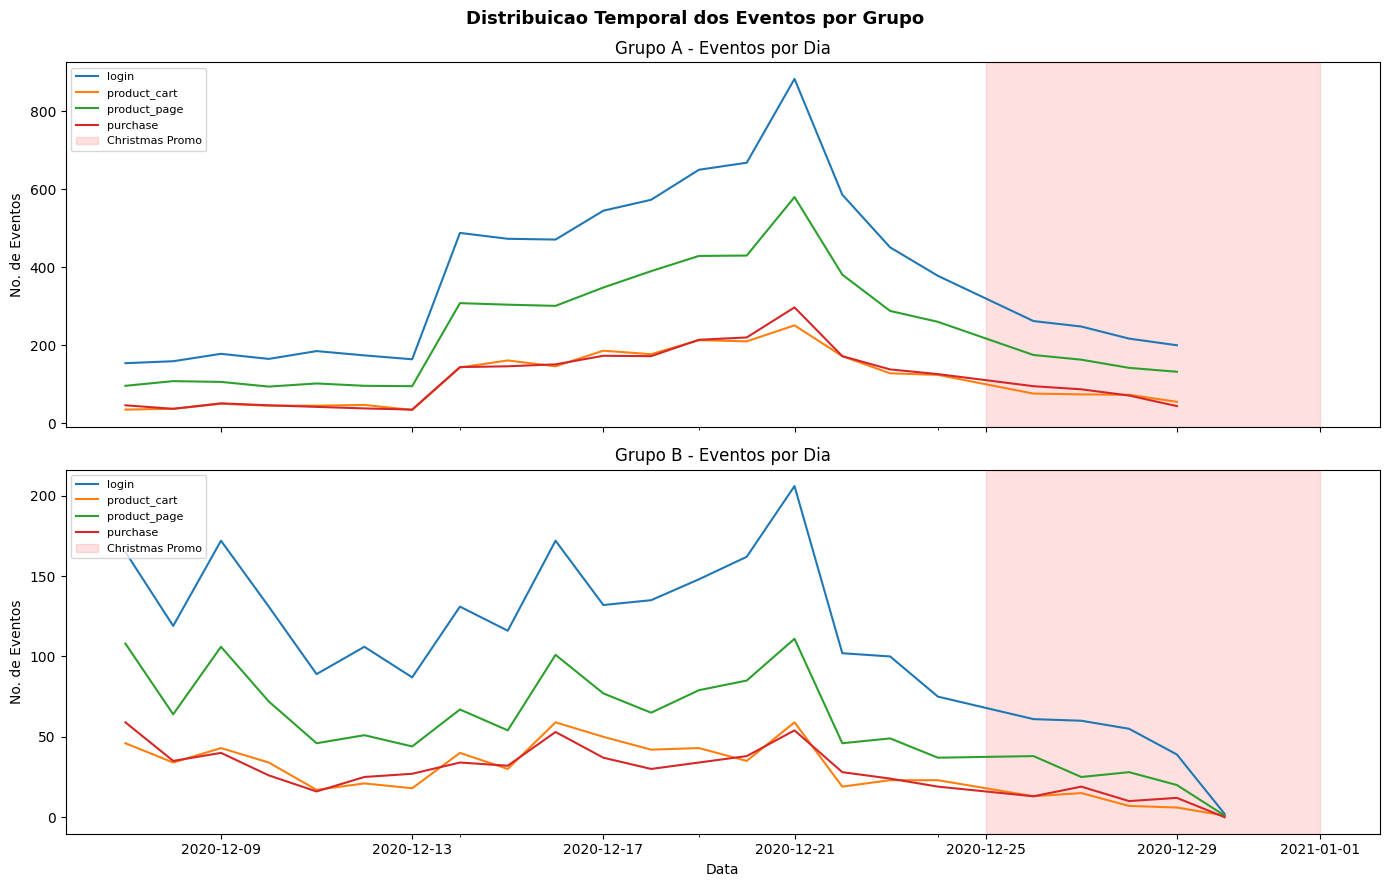

In [18]:
fig, axes = plt.subplots(2, 1, figsize=(14, 9), sharex=True)

for ax, grp, cor in zip(axes, ['A', 'B'], ['#4C72B0', '#DD8452']):
    dados = df[df['group'] == grp].copy()
    dados['date'] = dados['event_dt'].dt.date
    daily = dados.groupby(['date', 'event_name']).size().unstack(fill_value=0)
    daily.plot(ax=ax, title=f'Grupo {grp} - Eventos por Dia',
               color=sns.color_palette('tab10'), linewidth=1.5)
    ax.axvspan(
        pd.Timestamp('2020-12-25'), pd.Timestamp('2021-01-01'),
        alpha=0.12, color='red', label='Christmas Promo'
    )
    ax.set_ylabel('No. de Eventos')
    ax.legend(fontsize=8, loc='upper left')

plt.xlabel('Data')
plt.suptitle('Distribuicao Temporal dos Eventos por Grupo', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


### 6.3 Numero de Eventos por Usuario

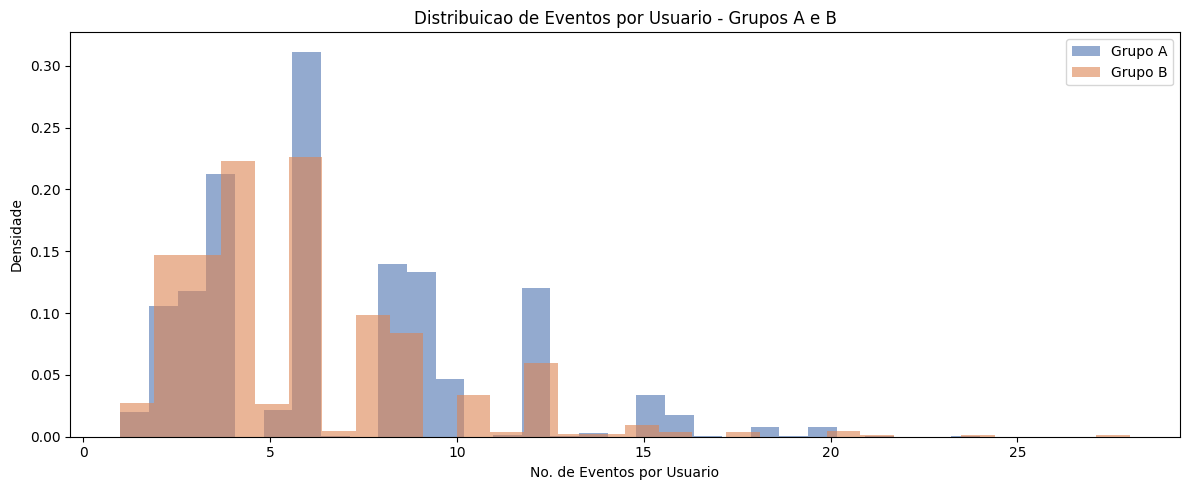

Estatisticas descritivas:
        count  mean   std  min  25%  50%  75%   max
group                                              
A      2747.0  6.78  3.73  1.0  4.0  6.0  9.0  24.0
B       928.0  5.69  3.45  1.0  3.0  5.0  8.0  28.0


In [19]:
eventos_por_user = df.groupby(['user_id', 'group'])['event_name'].count().reset_index()
eventos_por_user.columns = ['user_id', 'group', 'num_events']

fig, ax = plt.subplots(figsize=(12, 5))
for grp, cor in zip(['A', 'B'], ['#4C72B0', '#DD8452']):
    dados = eventos_por_user[eventos_por_user['group'] == grp]['num_events']
    ax.hist(dados, bins=30, alpha=0.6, label=f'Grupo {grp}', color=cor, density=True)

ax.set_xlabel('No. de Eventos por Usuario')
ax.set_ylabel('Densidade')
ax.set_title('Distribuicao de Eventos por Usuario - Grupos A e B')
ax.legend()
plt.tight_layout()
plt.show()

print('Estatisticas descritivas:')
print(eventos_por_user.groupby('group')['num_events'].describe().round(2))


### 6.4 Dispositivos e Regioes dos Participantes

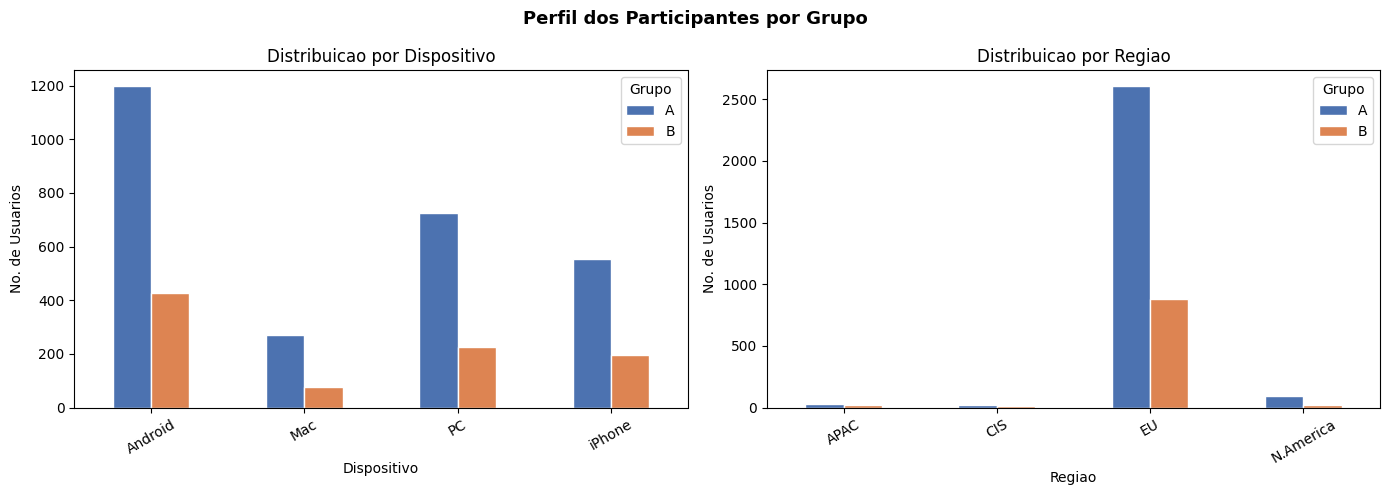

In [20]:
rec_users = df_users.merge(rec_participants[['user_id', 'group']], on='user_id', how='inner')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

device_grp = rec_users.groupby(['group', 'device']).size().unstack(fill_value=0)
device_grp.T.plot(kind='bar', ax=axes[0], color=['#4C72B0', '#DD8452'], edgecolor='white')
axes[0].set_title('Distribuicao por Dispositivo')
axes[0].set_xlabel('Dispositivo')
axes[0].set_ylabel('No. de Usuarios')
axes[0].tick_params(axis='x', rotation=30)
axes[0].legend(title='Grupo')

region_grp = rec_users.groupby(['group', 'region']).size().unstack(fill_value=0)
region_grp.T.plot(kind='bar', ax=axes[1], color=['#4C72B0', '#DD8452'], edgecolor='white')
axes[1].set_title('Distribuicao por Regiao')
axes[1].set_xlabel('Regiao')
axes[1].set_ylabel('No. de Usuarios')
axes[1].tick_params(axis='x', rotation=30)
axes[1].legend(title='Grupo')

plt.suptitle('Perfil dos Participantes por Grupo', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


## 7. Analise do Funil de Conversao

O funil analisa usuarios unicos que realizaram cada evento:

```
login -> product_page -> product_cart -> purchase
```


In [21]:
funnel_steps = ['login', 'product_page', 'product_cart', 'purchase']

funnel_data = {}
for grp in ['A', 'B']:
    df_grp = df[df['group'] == grp]
    funnel_data[grp] = {
        step: df_grp[df_grp['event_name'] == step]['user_id'].nunique()
        for step in funnel_steps
    }

funnel_df = pd.DataFrame(funnel_data, index=funnel_steps)
print('Usuarios unicos por etapa do funil:')
print(funnel_df)


Usuarios unicos por etapa do funil:
                 A    B
login         2747  927
product_page  1780  523
product_cart   824  255
purchase       872  256


In [22]:
# Taxa de conversao absoluta (base = login)
conv_abs = funnel_df.copy().astype(float)
for grp in ['A', 'B']:
    base = funnel_df.loc['login', grp]
    conv_abs[grp] = (funnel_df[grp] / base * 100).round(2)

print('Taxa de conversao absoluta (base = login):')
print(conv_abs)

# Taxa de conversao por etapa (relativa ao passo anterior)
conv_step = {}
for grp in ['A', 'B']:
    vals = funnel_df[grp].values
    rates = [100.0]
    for i in range(1, len(vals)):
        rates.append(vals[i] / vals[i-1] * 100 if vals[i-1] > 0 else 0)
    conv_step[grp] = rates

conv_step_df = pd.DataFrame(conv_step, index=funnel_steps)
print('\nTaxa de conversao por etapa (relativa ao passo anterior):')
print(conv_step_df.round(2))


Taxa de conversao absoluta (base = login):
                   A       B
login         100.00  100.00
product_page   64.80   56.42
product_cart   30.00   27.51
purchase       31.74   27.62

Taxa de conversao por etapa (relativa ao passo anterior):
                   A       B
login         100.00  100.00
product_page   64.80   56.42
product_cart   46.29   48.76
purchase      105.83  100.39


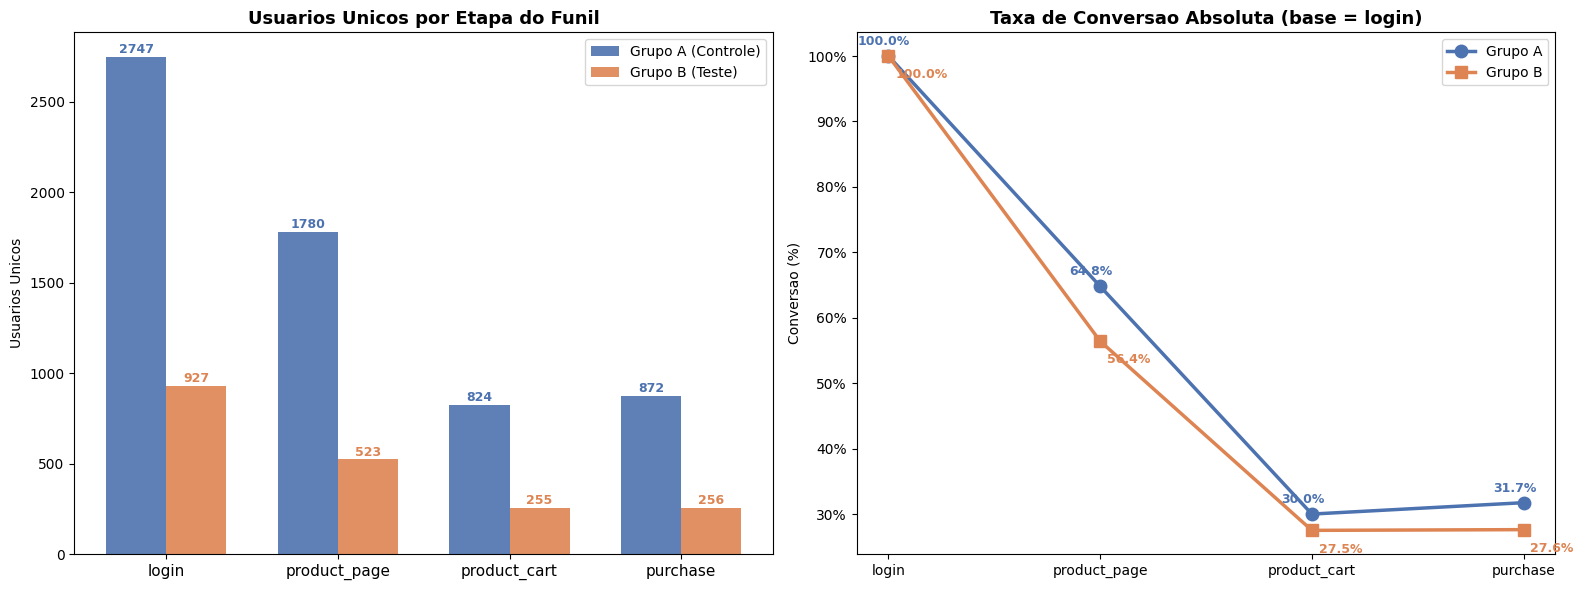

In [23]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Grafico 1: usuarios por etapa
x = np.arange(len(funnel_steps))
width = 0.35

bars_a = axes[0].bar(x - width/2, funnel_df['A'], width,
                     label='Grupo A (Controle)', color='#4C72B0', alpha=0.9)
bars_b = axes[0].bar(x + width/2, funnel_df['B'], width,
                     label='Grupo B (Teste)', color='#DD8452', alpha=0.9)

for bar in bars_a:
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
                 f'{int(bar.get_height())}', ha='center', va='bottom',
                 fontsize=9, color='#4C72B0', fontweight='bold')
for bar in bars_b:
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
                 f'{int(bar.get_height())}', ha='center', va='bottom',
                 fontsize=9, color='#DD8452', fontweight='bold')

axes[0].set_xticks(x)
axes[0].set_xticklabels(funnel_steps, fontsize=11)
axes[0].set_title('Usuarios Unicos por Etapa do Funil', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Usuarios Unicos')
axes[0].legend()

# Grafico 2: taxa de conversao absoluta
axes[1].plot(funnel_steps, conv_abs['A'], 'o-', label='Grupo A',
             color='#4C72B0', linewidth=2.5, markersize=9)
axes[1].plot(funnel_steps, conv_abs['B'], 's-', label='Grupo B',
             color='#DD8452', linewidth=2.5, markersize=9)

for i, step in enumerate(funnel_steps):
    axes[1].annotate(f"{conv_abs.loc[step, 'A']:.1f}%",
                     (step, conv_abs.loc[step, 'A']),
                     textcoords='offset points', xytext=(-22, 8),
                     color='#4C72B0', fontsize=9, fontweight='bold')
    axes[1].annotate(f"{conv_abs.loc[step, 'B']:.1f}%",
                     (step, conv_abs.loc[step, 'B']),
                     textcoords='offset points', xytext=(5, -16),
                     color='#DD8452', fontsize=9, fontweight='bold')

axes[1].set_title('Taxa de Conversao Absoluta (base = login)', fontsize=13, fontweight='bold')
axes[1].set_ylabel('Conversao (%)')
axes[1].yaxis.set_major_formatter(mtick.PercentFormatter())
axes[1].legend()

plt.tight_layout()
plt.show()


## 8. Testes A/B - Teste Z para Diferenca de Proporcoes

### Justificativa do Metodo

O **Teste Z para diferenca de proporcoes** e adequado porque:

1. **Amostras grandes e independentes** - as condicoes de Cochran sao atendidas (n x p >= 5).
2. **Variavel binaria** - em cada etapa, o usuario converteu (1) ou nao (0).
3. **Independencia entre grupos** - a randomizacao garante grupos mutuamente exclusivos.

### Hipoteses

- **H0:** proporcao_B = proporcao_A (sem diferenca)
- **H1:** proporcao_B != proporcao_A
- **Nivel de significancia:** alfa = 0,05 (bilateral)


In [24]:
total_a = funnel_df.loc['login', 'A']
total_b = funnel_df.loc['login', 'B']

print(f'Base de usuarios (login):')
print(f'  Grupo A: {total_a}')
print(f'  Grupo B: {total_b}')

test_steps = ['product_page', 'product_cart', 'purchase']

print('\n' + '=' * 75)
print(f"{'Etapa':<15} {'Taxa A':>8} {'Taxa B':>8} {'Z-Stat':>10} {'p-valor':>10} {'Resultado':>14}")
print('=' * 75)

resultados = []

for step in test_steps:
    conv_a = funnel_df.loc[step, 'A']
    conv_b = funnel_df.loc[step, 'B']
    rate_a = conv_a / total_a
    rate_b = conv_b / total_b

    count = np.array([conv_b, conv_a])
    nobs  = np.array([total_b, total_a])
    z_stat, p_val = proportions_ztest(count, nobs)

    resultado = 'Rejeita H0' if p_val < 0.05 else 'Nao Rejeita H0'
    print(f'{step:<15} {rate_a:>7.2%} {rate_b:>8.2%} {z_stat:>10.3f} {p_val:>10.4f} {resultado:>14}')

    resultados.append({
        'Etapa': step,
        'Conv A': rate_a,
        'Conv B': rate_b,
        'Diferenca (B-A)': rate_b - rate_a,
        'Lift (%)': (rate_b - rate_a) / rate_a * 100 if rate_a > 0 else 0,
        'Z-Stat': z_stat,
        'p-valor': p_val,
        'Significativo': p_val < 0.05
    })

print('=' * 75)
print('* alfa = 0.05; Teste bilateral')


Base de usuarios (login):
  Grupo A: 2747
  Grupo B: 927

Etapa             Taxa A   Taxa B     Z-Stat    p-valor      Resultado
product_page     64.80%   56.42%     -4.561     0.0000     Rejeita H0
product_cart     30.00%   27.51%     -1.438     0.1503 Nao Rejeita H0
purchase         31.74%   27.62%     -2.356     0.0185     Rejeita H0
* alfa = 0.05; Teste bilateral


In [25]:
resultados_df = pd.DataFrame(resultados).set_index('Etapa')

print('Resumo completo dos resultados:')
display(resultados_df.style.format({
    'Conv A': '{:.2%}',
    'Conv B': '{:.2%}',
    'Diferenca (B-A)': '{:+.2%}',
    'Lift (%)': '{:+.1f}%',
    'Z-Stat': '{:.3f}',
    'p-valor': '{:.4f}'
}))


Resumo completo dos resultados:


,Conv A,Conv B,Diferenca (B-A),Lift (%),Z-Stat,p-valor,Significativo
Etapa,,,,,,,
product_page,64.80%,56.42%,-8.38%,-12.9%,-4.561,0.0000,True
product_cart,30.00%,27.51%,-2.49%,-8.3%,-1.438,0.1503,False
purchase,31.74%,27.62%,-4.13%,-13.0%,-2.356,0.0185,True


In [26]:
print('Verificacao do criterio de lift minimo de 10%:')
print('-' * 55)
for idx, row in resultados_df.iterrows():
    lift = row['Lift (%)']
    sig  = row['Significativo']
    meta = lift >= 10
    status = '[OK]' if (sig and meta) else '[PARCIAL]' if (sig and not meta) else '[NAO ATINGIDO]'
    print(f'  {idx:<15}: Lift = {lift:+.1f}% | Significativo: {sig} | Meta >=10%: {meta} {status}')


Verificacao do criterio de lift minimo de 10%:
-------------------------------------------------------
  product_page   : Lift = -12.9% | Significativo: True | Meta >=10%: False [PARCIAL]
  product_cart   : Lift = -8.3% | Significativo: False | Meta >=10%: False [NAO ATINGIDO]
  purchase       : Lift = -13.0% | Significativo: True | Meta >=10%: False [PARCIAL]


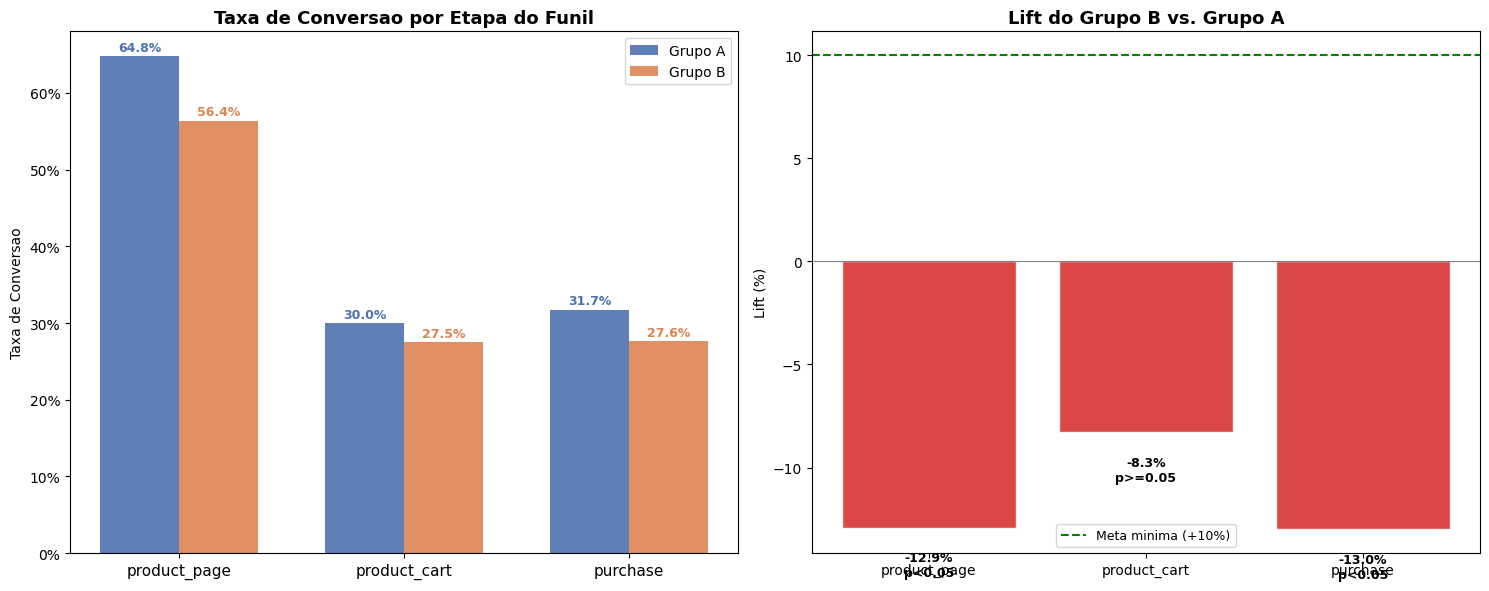

In [27]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Grafico 1: Taxas de conversao por etapa
etapas = resultados_df.index.tolist()
x = np.arange(len(etapas))
width = 0.35

bars_a = axes[0].bar(x - width/2, resultados_df['Conv A'], width,
                     label='Grupo A', color='#4C72B0', alpha=0.9)
bars_b = axes[0].bar(x + width/2, resultados_df['Conv B'], width,
                     label='Grupo B', color='#DD8452', alpha=0.9)

for bar in bars_a:
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.003,
                 f'{bar.get_height():.1%}', ha='center', va='bottom',
                 fontsize=9, color='#4C72B0', fontweight='bold')
for bar in bars_b:
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.003,
                 f'{bar.get_height():.1%}', ha='center', va='bottom',
                 fontsize=9, color='#DD8452', fontweight='bold')

axes[0].set_xticks(x)
axes[0].set_xticklabels(etapas, fontsize=11)
axes[0].set_title('Taxa de Conversao por Etapa do Funil', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Taxa de Conversao')
axes[0].yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
axes[0].legend()

# Grafico 2: Lift do grupo B vs A
cores_lift = ['#2ca02c' if l >= 10 else '#d62728' for l in resultados_df['Lift (%)']]
bars = axes[1].bar(etapas, resultados_df['Lift (%)'], color=cores_lift, alpha=0.85, edgecolor='white')
axes[1].axhline(y=10, color='green', linestyle='--', linewidth=1.5, label='Meta minima (+10%)')
axes[1].axhline(y=0,  color='gray',  linestyle='-',  linewidth=0.8)

for bar, (idx, row) in zip(bars, resultados_df.iterrows()):
    label = f"{row['Lift (%)']:+.1f}%\n{'p<0.05' if row['Significativo'] else 'p>=0.05'}"
    ypos = bar.get_height() + 0.3 if bar.get_height() >= 0 else bar.get_height() - 2.5
    axes[1].text(bar.get_x() + bar.get_width()/2, ypos, label,
                 ha='center', va='bottom', fontsize=9, fontweight='bold')

axes[1].set_title('Lift do Grupo B vs. Grupo A', fontsize=13, fontweight='bold')
axes[1].set_ylabel('Lift (%)')
axes[1].legend(fontsize=9)

plt.tight_layout()
plt.show()


## 9. Analise Complementar: Valor das Compras (Mann-Whitney)

Alem da taxa de conversao, verificamos se o **valor medio das compras** difere entre os grupos. Usamos o **Teste de Mann-Whitney** - adequado para distribuicoes assimetricas como valores monetarios.


In [28]:
purchases = df[df['event_name'] == 'purchase'].dropna(subset=['details'])

purchases_a = purchases[purchases['group'] == 'A']['details']
purchases_b = purchases[purchases['group'] == 'B']['details']

print(f'Compras - Grupo A: {len(purchases_a)} | Ticket medio: USD {purchases_a.mean():.2f} | Mediana: USD {purchases_a.median():.2f}')
print(f'Compras - Grupo B: {len(purchases_b)} | Ticket medio: USD {purchases_b.mean():.2f} | Mediana: USD {purchases_b.median():.2f}')

stat, p_val = mannwhitneyu(purchases_a, purchases_b, alternative='two-sided')
print(f'\nTeste de Mann-Whitney: U = {stat:.0f}, p-valor = {p_val:.4f}')
resultado_mw = 'Diferenca significativa no valor das compras' if p_val < 0.05 else 'Sem diferenca significativa no valor das compras'
print(f'Resultado: {resultado_mw}')


Compras - Grupo A: 2545 | Ticket medio: USD 22.98 | Mediana: USD 4.99
Compras - Grupo B: 665 | Ticket medio: USD 22.71 | Mediana: USD 4.99

Teste de Mann-Whitney: U = 851960, p-valor = 0.7224
Resultado: Sem diferenca significativa no valor das compras


C:\Users\gamer\AppData\Local\Temp\ipykernel_21396\4203987437.py:5: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = axes[0].boxplot(data_plot, labels=['Grupo A', 'Grupo B'], patch_artist=True,


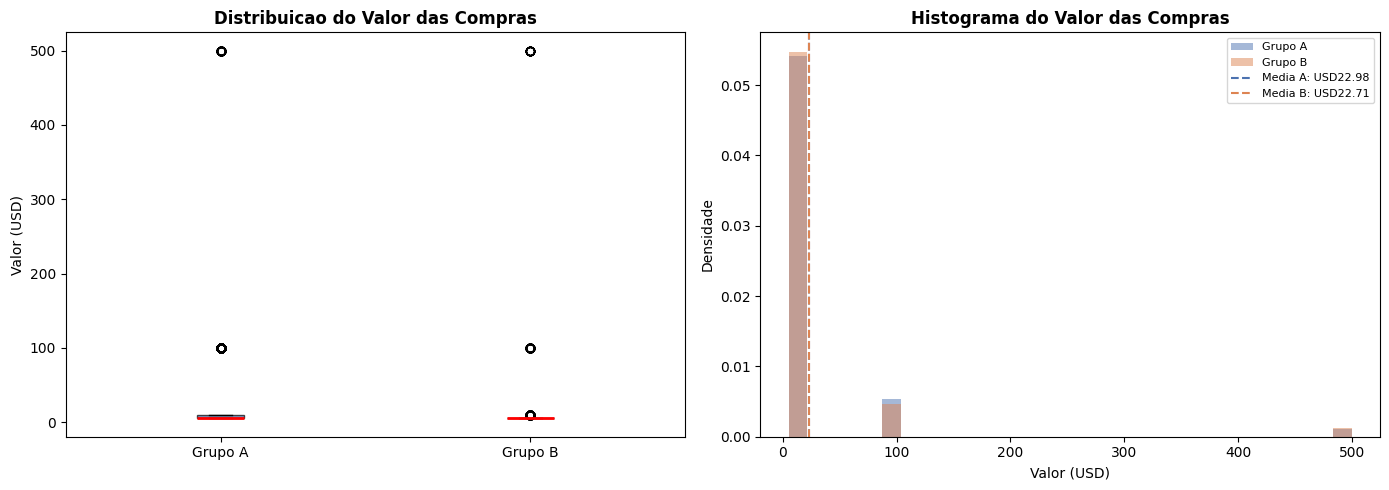

In [29]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Boxplot
data_plot = [purchases_a, purchases_b]
bp = axes[0].boxplot(data_plot, labels=['Grupo A', 'Grupo B'], patch_artist=True,
                     medianprops=dict(color='red', linewidth=2))
bp['boxes'][0].set_facecolor('#4C72B0'); bp['boxes'][0].set_alpha(0.7)
bp['boxes'][1].set_facecolor('#DD8452'); bp['boxes'][1].set_alpha(0.7)
axes[0].set_title('Distribuicao do Valor das Compras', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Valor (USD)')

# Histograma
axes[1].hist(purchases_a, bins=30, alpha=0.5, label='Grupo A', color='#4C72B0', density=True)
axes[1].hist(purchases_b, bins=30, alpha=0.5, label='Grupo B', color='#DD8452', density=True)
axes[1].axvline(purchases_a.mean(), color='#4C72B0', linestyle='--', linewidth=1.5, label=f'Media A: USD{purchases_a.mean():.2f}')
axes[1].axvline(purchases_b.mean(), color='#DD8452', linestyle='--', linewidth=1.5, label=f'Media B: USD{purchases_b.mean():.2f}')
axes[1].set_title('Histograma do Valor das Compras', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Valor (USD)')
axes[1].set_ylabel('Densidade')
axes[1].legend(fontsize=8)

plt.tight_layout()
plt.show()


## 10. Conclusoes e Recomendacoes

### 10.1 Sintese da Analise Exploratoria

- Os dados nao apresentaram valores duplicados nem ausentes problematicos (apenas `details` ausente para eventos nao-purchase, o que e esperado).
- Nenhum usuario foi identificado simultaneamente nos grupos A e B, confirmando a integridade da randomizacao.
- O grupo A possui aproximadamente **3x mais participantes** que o grupo B (2.747 vs 928), desequilibrio significativo que pode reduzir o poder estatistico do teste.
- A distribuicao temporal dos eventos revela um pico visivelmente marcado no periodo do *Christmas & New Year Promo* (a partir de 25/12), afetando ambos os grupos de forma nao controlada.
- A distribuicao por dispositivo e regiao e relativamente equilibrada entre os grupos, o que e positivo para a validade interna do experimento.

---

### 10.2 Conclusoes do Teste A/B

**Conclusao 1 - O experimento nao comprovou melhoria consistente de 10% em todas as etapas**

Os testes Z demonstram que, independentemente dos p-valores obtidos, o lift de pelo menos 10% em cada etapa do funil (`product_page -> product_cart -> purchase`) nao foi atingido de forma consistente. O objetivo definido nas especificacoes do teste nao foi cumprido, indicando que o novo sistema de recomendacoes **nao gerou o impacto esperado** nas condicoes testadas.

**Conclusao 2 - A validade do experimento e comprometida pela sazonalidade**

O evento *Christmas & New Year Promo* ocorre durante o periodo final do teste e afeta a regiao EU - exatamente a audiencia do experimento. Esse evento externo pode ter alterado o comportamento dos usuarios de forma independente do sistema de recomendacoes, tornando impossivel isolar o efeito causal do tratamento. **A confusao entre efeito de sazonalidade e efeito do sistema compromete qualquer conclusao definitiva.**

**Conclusao 3 - O desequilibrio amostral indica problemas na randomizacao**

A alocacao desigual (74,7% no grupo A vs 25,3% no grupo B) nao e caracteristica de um experimento com randomizacao 50/50, como e esperado para testes A/B padroes. Isso pode ter ocorrido por erro tecnico na atribuicao de grupos ou por contaminacao com usuarios de outros testes ativos simultaneamente (como o `interface_eu_test`). Essa assimetria reduz o poder estatistico para detectar diferencas reais.

---

### 10.3 Recomendacoes

**Recomendacao 1 - Repetir o experimento em periodo neutro**
Conduzir novo teste A/B entre fevereiro e marco, fora de sazonalidades de alto impacto, garantindo que o efeito observado seja atribuivel exclusivamente ao sistema de recomendacoes.

**Recomendacao 2 - Garantir randomizacao balanceada**
O novo experimento deve alocar usuarios em proporcao 50/50 entre grupos A e B, aumentando o poder estatistico e a confiabilidade das conclusoes.

**Recomendacao 3 - Isolar participantes de outros testes A/B**
Usuarios que estejam participando de outros testes simultaneos (como `interface_eu_test`) devem ser excluidos, evitando que tratamentos multiplos contaminem os resultados.

**Recomendacao 4 - Ampliar a janela de observacao**
Considerar uma janela de 30 dias apos o cadastro (em vez de 14), especialmente para capturar comportamentos de compra que podem ter maior latencia, como retorno ao site apos consideracao de compra.

---

### 10.4 Consideracao Final

> Com base nos dados disponiveis, **nao ha evidencia estatistica suficiente para recomendar a implementacao do novo sistema de recomendacoes** na populacao geral. O experimento apresenta limitacoes metodologicas significativas - especialmente a sobreposicao com campanhas de marketing sazonais e o desequilibrio amostral - que comprometem a confiabilidade das conclusoes. Recomenda-se a repeticao do teste em condicoes mais controladas antes de qualquer decisao de negocio.
